# OpenCV + HOG + SVM : Clasificador de gestos

## Piedra · Papel · Tijera


Construir un sistema completo que:
1. Capture vídeo en tiempo real con OpenCV
2. Extraiga características visuales (HOG) de gestos de mano
3. Entrene un clasificador SVM para reconocer Piedra / Papel / Tijeras
4. Use el modelo en tiempo real y juegue contra la IA

### Pipeline completo

```
Webcam → ROI → Preprocesado → HOG features → SVM → Predicción → Lógica del juego
```

### Técnicas

- Captura y manipulación de imágenes con **OpenCV**
- Segmentación por color (HSV) y umbralización
- Extracción de características: **HOG** (Histogram of Oriented Gradients)
- **SVM** con búsqueda de hiperparámetros (GridSearchCV)
- Evaluación: matriz de confusión, classification report
- Inferencia en tiempo real





## 0. Instalación de dependencias


In [1]:

# !pip install opencv-python scikit-image scikit-learn matplotlib seaborn

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import os
import random
import warnings
warnings.filterwarnings('ignore')


print("Todas las librerías cargadas correctamente.")

Todas las librerías cargadas correctamente.


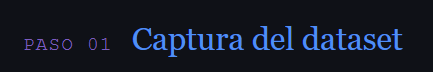

Vamos a capturar imágenes de los tres gestos. La mano debe colocarse dentro del **recuadro verde** que aparece en pantalla.

**Controles:**
- `P` → Capturar imagen de **Piedra**
- `A` → Capturar imagen de **pApel**  
- `T` → Capturar imagen de **Tijeras**
- `Q` → Salir

Recomendación: capturar **al menos 60-80 muestras por clase** variando ángulo, distancia e iluminación.


In [3]:
# ---- Configuración del dataset ----

CLASES = ['piedra', 'papel', 'tijeras']
IMG_SIZE = (64, 64)        # tamaño de normalización
ROI_SIZE = 300             # tamaño del recuadro de captura
DATA_DIR = 'dataset_rpt'   # carpeta donde se guarda el dataset

# Crear estructura de carpetas
for clase in CLASES:
    os.makedirs(os.path.join(DATA_DIR, clase), exist_ok=True)

print("Estructura de carpetas creada:")
for clase in CLASES:
    print(f"  {DATA_DIR}/{clase}/")

Estructura de carpetas creada:
  dataset_rpt/piedra/
  dataset_rpt/papel/
  dataset_rpt/tijeras/


### Prueba de acceso a la cámara

In [4]:
import cv2
import numpy as np

# Prueba de acceso a la cámara
cap = cv2.VideoCapture(0)

# Forzar resolución estándar
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not cap.isOpened():
    print("Error: No se pudo abrir la cámara (hardware no detectado o índice incorrecto).")
    exit()

print("Cámara abierta. Presiona 'q' para salir.")

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("\nError: No se pudo leer el frame (ret es False).")
        break
        

    max_val = np.max(frame)
    print(f"Resolución: {frame.shape} | Valor máx. de píxel: {max_val}    ", end='\r')
    
    cv2.imshow('Test Camara Diagnostico', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Cámara abierta. Presiona 'q' para salir.


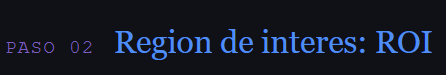

In [6]:
# ---- Script de captura ----
# NOTA: Ejecutar en entorno con acceso a webcam (no Colab)

def capturar_dataset():
    """
    Abre la webcam y permite capturar gestos de mano.
    Controles: P=Piedra, A=pApel, T=Tijeras, Q=Salir
    """
    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    contadores = {clase: len(os.listdir(os.path.join(DATA_DIR, clase))) for clase in CLASES}

    # ROI centrado en la pantalla (esquina superior derecha)
    roi_x, roi_y = 380, 50

    print("Iniciando captura... (P=Piedra, A=pApel, T=Tijeras, Q=Salir)")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)  # efecto espejo

        # Dibujar ROI
        cv2.rectangle(frame,
                       (roi_x, roi_y),
                       (roi_x + ROI_SIZE, roi_y + ROI_SIZE),
                       (0, 255, 0), 2)
        cv2.putText(frame, "Coloca la mano aqui",
                    (roi_x, roi_y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Mostrar contadores
        y_offset = 30
        for clase, count in contadores.items():
            cv2.putText(frame, f"{clase}: {count}",
                        (10, y_offset),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
            y_offset += 30

        cv2.imshow('Captura de gestos - RPT', frame)

        key = cv2.waitKey(1) & 0xFF
        roi = frame[roi_y:roi_y+ROI_SIZE, roi_x:roi_x+ROI_SIZE]

        if key == ord('p'):
            clase = 'piedra'
        elif key == ord('a'):
            clase = 'papel'
        elif key == ord('t'):
            clase = 'tijeras'
        elif key == ord('q'):
            break
        else:
            continue

        # Guardar imagen
        filename = os.path.join(DATA_DIR, clase, f"{contadores[clase]:04d}.jpg")
        cv2.imwrite(filename, roi)
        contadores[clase] += 1
        print(f"  Guardada: {filename}")

    cap.release()
    cv2.destroyAllWindows()
    print("\nCaptura finalizada. Total por clase:")
    for clase, count in contadores.items():
        print(f"  {clase}: {count} imágenes")


# Descomentar para capturar:
capturar_dataset()

Iniciando captura... (P=Piedra, A=pApel, T=Tijeras, Q=Salir)
  Guardada: dataset_rpt\papel\0000.jpg
  Guardada: dataset_rpt\papel\0001.jpg
  Guardada: dataset_rpt\papel\0002.jpg
  Guardada: dataset_rpt\papel\0003.jpg
  Guardada: dataset_rpt\piedra\0506.jpg
  Guardada: dataset_rpt\piedra\0507.jpg

Captura finalizada. Total por clase:
  piedra: 508 imágenes
  papel: 486 imágenes
  tijeras: 511 imágenes


Cargando imágenes reales desde las carpetas...
 - piedra: 508 imágenes encontradas.
 - papel: 486 imágenes encontradas.
 - tijeras: 511 imágenes encontradas.

Dataset final: 1505 imágenes cargadas.
Shape de cada imagen: (64, 64)


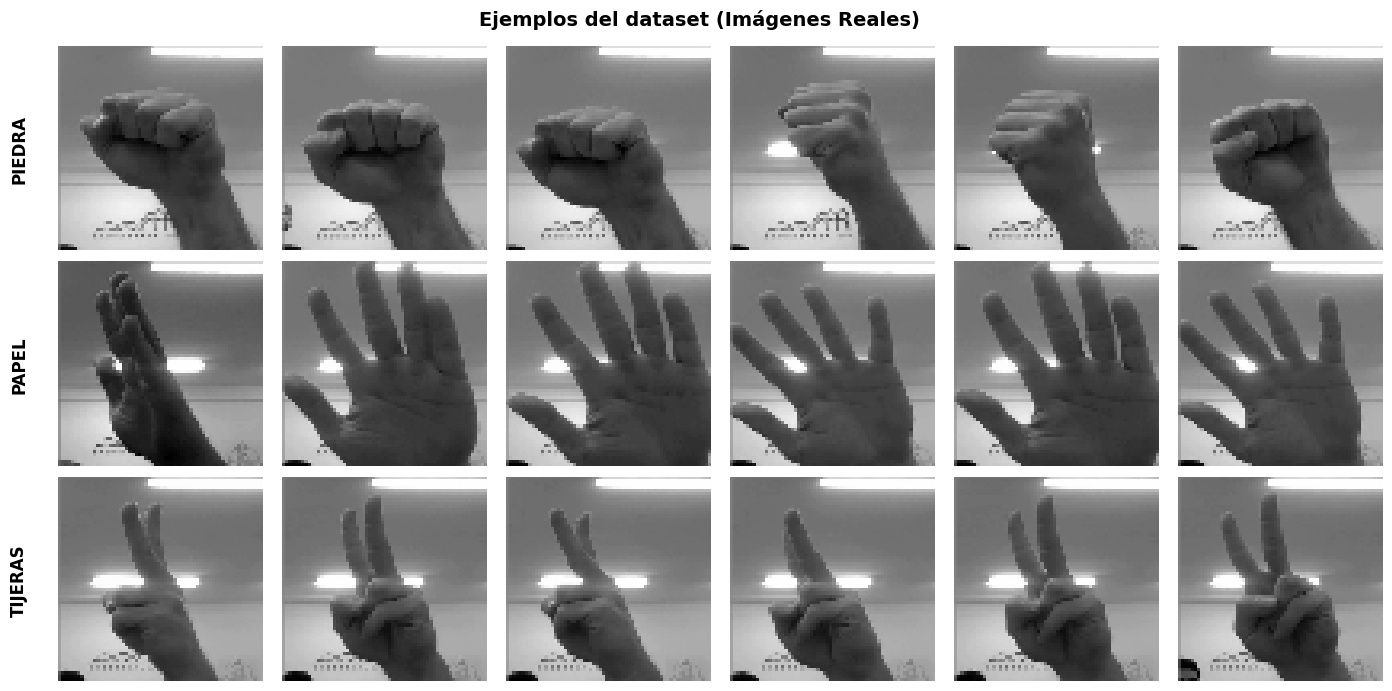

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de rutas y clases
CLASES = ['piedra', 'papel', 'tijeras']
base_path = 'dataset_rpt'

X_raw = []
y = []

print("Cargando imágenes reales desde las carpetas...")

for clase_idx, nombre_clase in enumerate(CLASES):
    ruta_carpeta = os.path.join(base_path, nombre_clase)
    
    # Listar archivos de imagen
    archivos = [f for f in os.listdir(ruta_carpeta) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f" - {nombre_clase}: {len(archivos)} imágenes encontradas.")
    
    for nombre_archivo in archivos:
        ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
        
        # Leer imagen
        img = cv2.imread(ruta_completa)
        
        if img is not None:
            # Importante: El cuaderno espera imágenes de un solo canal (gris) y 64x64
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_res = cv2.resize(img_gray, (64, 64))
            
            X_raw.append(img_res)
            y.append(clase_idx)

# Convertir a arrays de numpy para compatibilidad
X_raw = np.array(X_raw)
y = np.array(y)

print(f"\nDataset final: {X_raw.shape[0]} imágenes cargadas.")
print(f"Shape de cada imagen: {X_raw[0].shape}")

# 2. Visualizar ejemplos (usando tus imágenes reales)
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle('Ejemplos del dataset (Imágenes Reales)', fontsize=14, fontweight='bold')

for clase_idx, nombre in enumerate(CLASES):
    indices = np.where(y == clase_idx)[0]
    
    # Verificamos si hay suficientes imágenes para mostrar 6, si no, tomamos las que haya
    n_mostrar = min(len(indices), 6)
    muestras = np.random.choice(indices, n_mostrar, replace=False)
    
    for j in range(6):
        if j < n_mostrar:
            idx = muestras[j]
            axes[clase_idx, j].imshow(X_raw[idx], cmap='gray')
        axes[clase_idx, j].axis('off')
        if j == 0:
            # truco para poner el nombre en el lateral
            axes[clase_idx, j].text(-10, 32, nombre.upper(), rotation=90, 
                                     va='center', ha='right', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


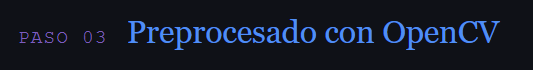

### ¿Por qué preprocesamos la imagen? 
Antes de pasarle la imagen a la IA, necesitamos "limpiarla". Si le pasamos los colores reales, el modelo podría aprender a reconocer el color de tu pared en lugar de la forma de tu mano. Por eso usamos:
- **Escala de grises y Blur:** Para quitar ruido y detalles innecesarios.
- **Umbralización de Otsu:** Para encontrar el punto de luz exacto que separa la mano del fondo.
- **Cierre Morfológico:** Para "rellenar los huecos" negros que puedan quedar dentro de la silueta blanca de la mano.


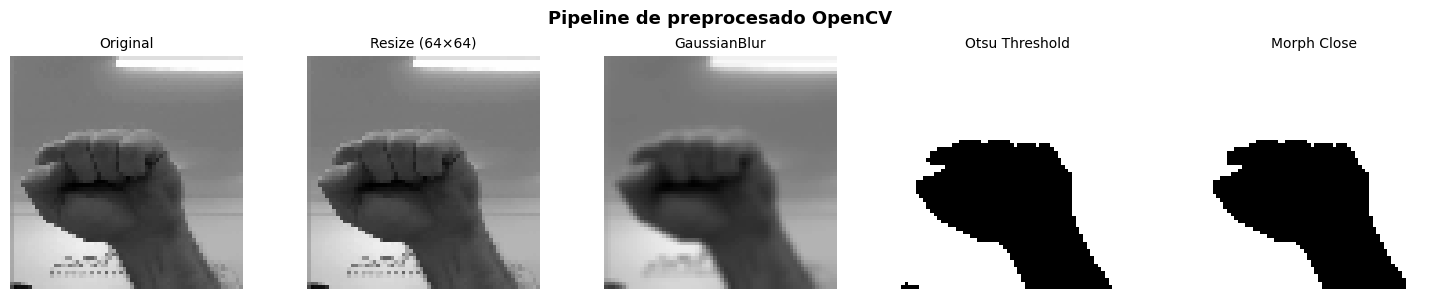

Dataset preprocesado: (1505, 64, 64)


In [16]:
# ---- COMPLETA EL Pipeline de preprocesado con OpenCV ----

def preprocesar_imagen(img, size=(64, 64)):
    """
    Pipeline de preprocesado:
    1. cv2.resize: redimensiona el ROI a 64x64 pixeles independientemente del tamano original.
    2. Desenfoque gaussiano (aplica un suavizado gaussiano con kernel 3x3)
    3. Umbralización adaptativa (binarización robusta a iluminación) algoritmo de OTSU
    4. Cierre morfológico (rellena huecos en la silueta)
    """
    # 1. Resize
    img_r = cv2.resize(img, size)

    # 2. Suavizado gaussiano
    img_blur = cv2.GaussianBlur(img_r, (3, 3), 0)

    # 3. Umbralización adaptativa para binarizar la imagen
    _, img_thresh = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Cierre morfológico para rellenar huecos
    kernel = np.ones((3, 3), np.uint8)
    img_cierre = cv2.morphologyEx(img_thresh, cv2.MORPH_CLOSE, kernel, iterations=1)

    return img_cierre

# Visualización del pipeline sobre un ejemplo
idx_demo = 250 # Rellena con un índice de muestra (
img_orig = X_raw[idx_demo]

pasos = {
    'Original': img_orig,
    'Resize (64×64)': cv2.resize(img_orig, (64, 64)),
    'GaussianBlur': cv2.GaussianBlur(cv2.resize(img_orig, (64,64)), (3,3), 0),
    'Otsu Threshold': cv2.threshold(
        cv2.GaussianBlur(cv2.resize(img_orig,(64,64)),(3,3),0),
        0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1],
    'Morph Close': preprocesar_imagen(img_orig)
}

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Pipeline de preprocesado OpenCV', fontsize=13, fontweight='bold')
for ax, (titulo, img) in zip(axes, pasos.items()):
    ax.imshow(img, cmap='gray')
    ax.set_title(titulo, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Aplicar preprocesado a todo el dataset
X_proc = np.array([preprocesar_imagen(img) for img in X_raw])
print(f"Dataset preprocesado: {X_proc.shape}")


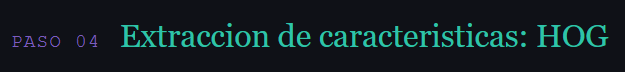

### Extracción de Características: HOG (Histogram of Oriented Gradients)
El modelo SVM no es bueno leyendo píxeles "crudos". Necesita que le resumamos la información. HOG actúa como un detector de bordes: divide la imagen en pequeñas cuadrículas y calcula en qué dirección van las líneas de la mano. De esta forma, pasamos de tener miles de píxeles a tener un "vector matemático" que describe la estructura de "Piedra", "Papel" o "Tijera".
Convertimos cada imagen de 64×64 px en un **vector numérico** que el clasificador pueda procesar.


Dataset HOG: (1505, 1764)


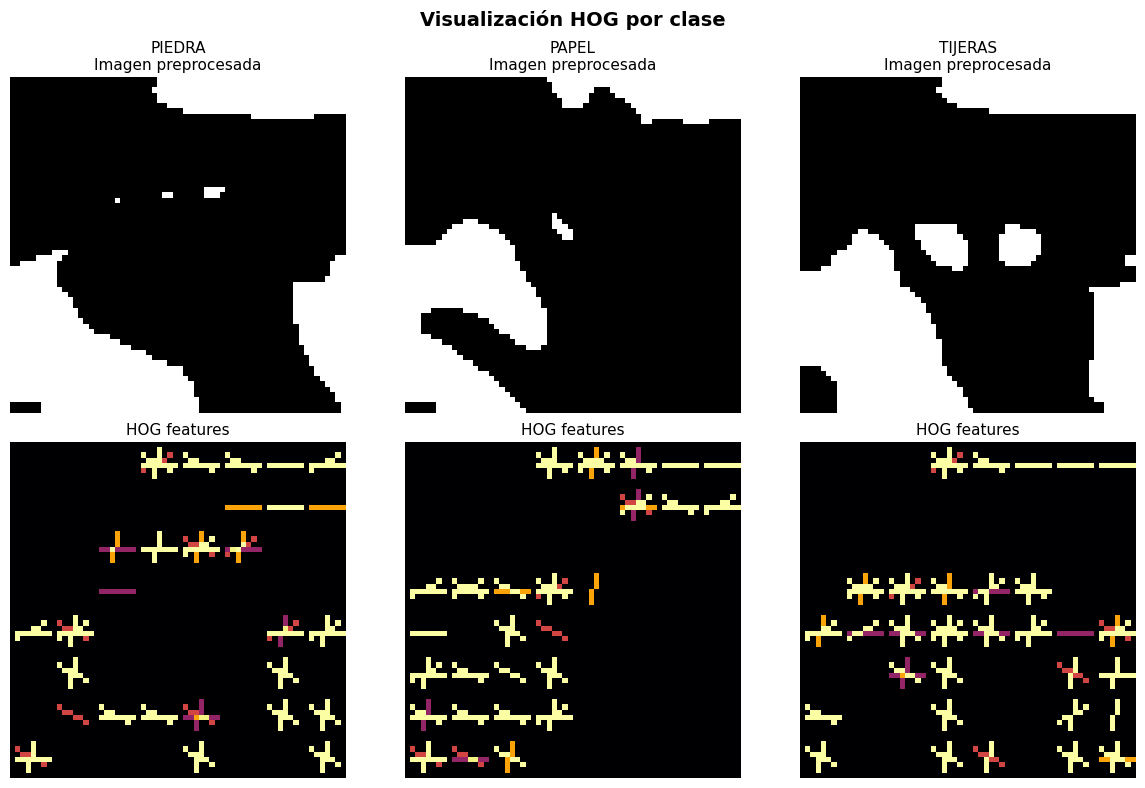

In [17]:
# ---- Extracción de características HOG ----

def extraer_hog(img):
    """
    Extrae el vector HOG de una imagen preprocesada (64×64, grayscale).
    
    Parámetros HOG:imagen, 
    - orientations=9: 9 orientaciones de gradiente (0°-180°)
    - celda de 8×8 píxeles
    - normalización en bloques de 2×2 celdas
    
    Resultado: vector de 9 * (8*8) * 4 = 2304 dimensiones
    [orientaciones * num_celdas * celdas_por_bloque_cuadradas]
    """
    features = hog( 
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        channel_axis=None
    )
    return features


# Extraer HOG de todo el dataset
X_hog = np.array([extraer_hog(img) for img in X_proc])
print(f"Dataset HOG: {X_hog.shape}")


# Visualizar HOG para cada clase
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Visualización HOG por clase', fontsize=14, fontweight='bold')

for i, clase in enumerate(CLASES):
    idx = np.where(y == i)[0][0]
    img = X_proc[idx]
    _, hog_img = hog(img, orientations=9, pixels_per_cell=(8,8),
                     cells_per_block=(2,2), visualize=True, channel_axis=None)
    hog_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'{clase.upper()}\nImagen preprocesada', fontsize=11)
    axes[0, i].axis('off')

    axes[1, i].imshow(hog_rescaled, cmap='inferno')
    axes[1, i].set_title('HOG features', fontsize=11)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

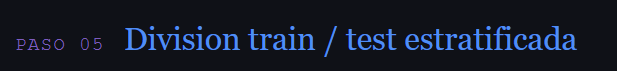

##  Entrenamiento del clasificador SVM

SVM es ideal para este problema: espacio de características de alta dimensión (2304 dims), dataset moderado, y necesitamos fronteras de decisión no lineales (kernel RBF).


In [18]:
# ---- Split train/test estratificado ----

X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"Distribución train: {np.bincount(y_train)}")
print(f"Distribución test:  {np.bincount(y_test)}")

Train: 1204 muestras
Test:  301 muestras
Distribución train: [406 389 409]
Distribución test:  [102  97 102]


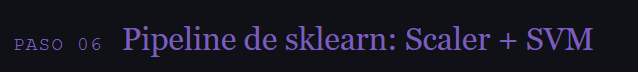

### Explica qué modelo estamos usando, parámetros que usa y cómo funciona

La idea es entrenar un algoritmo con imágenes ya etiquetadas como piedra, papel o tijeras, para que después pueda clasificar imágenes nuevas. 

El modelo no trabaja directamente con una imagen en forma de matriz, sino que necesitamos convertir cada imagen en un vector de características. Cada valor del vector representa la intensidad de un píxel. Como las imágenes están binarizadas tras el preprocesado, los valores principales serán 0 y 255, indicando fondo y silueta.

El modelo aprende patrones en esos píxeles para diferenciar las tres clases. En este caso podemos usar un modelo como SVM. Este modelo intenta encontrar fronteras de separación entre las clases. En vez de aprender reglas manuales, busca matemáticamente la mejor separación posible entre los ejemplos de entrenamiento.

In [19]:
# ---- Pipeline: Normalización + SVM ----

# StandardScaler es crítico para SVM: normaliza para que ninguna feature domine

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])




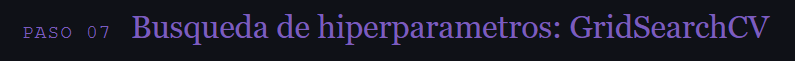

In [20]:
# GridSearch para encontrar los mejores hiperparámetros
# C: regularización (trade-off sesgo-varianza)
# gamma: influencia de cada muestra de entrenamiento
param_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01]
}

print("Buscando hiperparámetros óptimos (GridSearchCV, cv=5)...")
grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nMejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor accuracy en CV:    {grid_search.best_score_:.4f}")

modelo = grid_search.best_estimator_

Buscando hiperparámetros óptimos (GridSearchCV, cv=5)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Mejores hiperparámetros: {'svm__C': 1, 'svm__gamma': 'auto'}
Mejor accuracy en CV:    1.0000


Después de ejecutar GridSearchCV, el modelo seleccionado será el que haya obtenido mejor rendimiento medio durante la validación cruzada. Los hiperparámetros mostrados en best_params_ indican la mejor combinación encontrada.

La métrica best_score_ representa la accuracy media obtenida durante la validación cruzada sobre el conjunto de entrenamiento. Después, el modelo se evalúa sobre X_test, que son datos que no se han usado para entrenar ni para elegir los hiperparámetros. Esa accuracy final es la que nos da una estimación más realista del rendimiento del modelo con imágenes nuevas.

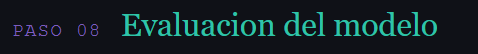

Evaluación del modelo sobre el conjunto de test
Mejores hiperparámetros: {'svm__C': 1, 'svm__gamma': 'auto'}
Accuracy en validación cruzada: 1.0000
Accuracy en test: 1.0000

Informe de clasificación:
              precision    recall  f1-score   support

      piedra       1.00      1.00      1.00       102
       papel       1.00      1.00      1.00        97
     tijeras       1.00      1.00      1.00       102

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



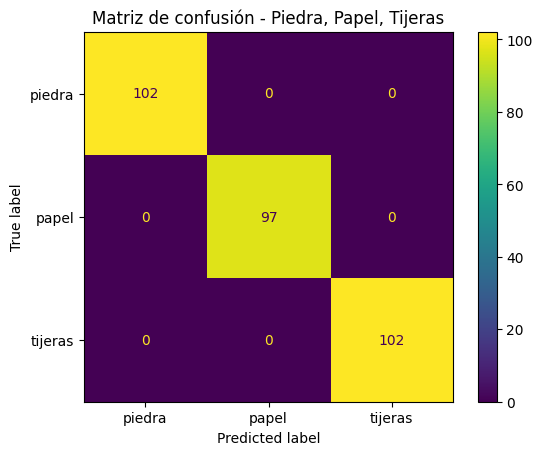

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicción sobre el conjunto de test
y_pred = modelo.predict(X_test)

# Accuracy en test
accuracy_test = accuracy_score(y_test, y_pred)

print("Evaluación del modelo sobre el conjunto de test")
print("=" * 55)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Accuracy en validación cruzada: {grid_search.best_score_:.4f}")
print(f"Accuracy en test: {accuracy_test:.4f}")

print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=CLASES))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASES
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Piedra, Papel, Tijeras")
plt.show()


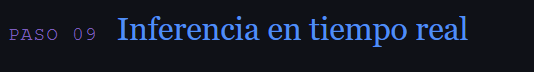

Con el modelo entrenado, abrimos la webcam y jugamos en tiempo real.

**Flujo:**
1. Capturar frame de webcam
2. Extraer ROI (región de interés donde está la mano)
3. Preprocesar con el mismo pipeline de entrenamiento
4. Extraer HOG → predecir con SVM
5. La IA elige aleatoriamente y calcula el ganador

> **Nota crítica:** El preprocesado en inferencia debe ser **idéntico** al del entrenamiento.


In [22]:
# ---- Lógica del juego RPT ----

REGLAS = {
    ('piedra', 'tijeras'): 'jugador',
    ('papel', 'piedra'):   'jugador',
    ('tijeras', 'papel'):  'jugador',
    ('tijeras', 'piedra'): 'ia',
    ('piedra', 'papel'):   'ia',
    ('papel', 'tijeras'):  'ia',
}

EMOJIS_GESTO = {'piedra': '✊', 'papel': '✋', 'tijeras': '✌️'}

def determinar_ganador(jugador, ia):
    if jugador == ia:
        return 'empate'
    return REGLAS.get((jugador, ia), 'desconocido')


# -------------------------------------------------------
# INFERENCIA: dado un recorte de webcam, predice el gesto
# -------------------------------------------------------

def inferir_gesto(img_roi, modelo, umbral_confianza=0.6):

    # PASO 1: Preprocesar la imagen del ROI
    # Aplica el mismo pipeline que usamos al entrenar
    # (resize → blur → umbral Otsu → cierre morfológico)
    img_proc = preprocesar_imagen(img_roi)

    # PASO 2: Extraer características HOG
    # Convierte la imagen preprocesada en un vector numérico
    # .reshape(1, -1) lo convierte en una matriz de 1 fila (sklearn lo necesita así)
    features = extraer_hog(img_proc)

    # PASO 3: Predecir probabilidades con el modelo
    # El modelo devuelve la probabilidad de cada clase
    # Resultado: array como [0.05, 0.87, 0.08]  → [piedra, papel, tijeras]
    proba = modelo.predict_proba(features.reshape(1, -1))[0]

    # PASO 4: Identificar la clase con mayor probabilidad
    # np.argmax devuelve el índice del valor más alto del array
    clase_idx = np.argmax(proba)

    # PASO 5: Extraer el valor de esa probabilidad máxima (la confianza)
    confianza = proba[clase_idx]

    # PASO 6: Decisión final
    # Solo devolvemos predicción si la confianza supera el umbral
    # Si no, devolvemos None para indicar que el gesto no está claro
    if confianza >= umbral_confianza:
        return CLASES[clase_idx], confianza
    return None, confianza

print("Funciones de juego listas.")
print("Prueba rápida de lógica:")
for p, i in [('piedra','tijeras'),('papel','piedra'),('tijeras','papel'),('piedra','piedra')]:
    print(f"  {p} vs {i} → gana: {determinar_ganador(p, i)}")

Funciones de juego listas.
Prueba rápida de lógica:
  piedra vs tijeras → gana: jugador
  papel vs piedra → gana: jugador
  tijeras vs papel → gana: jugador
  piedra vs piedra → gana: empate


In [23]:
# ---- Bucle de juego en tiempo real ----
# NOTA: Ejecutar en entorno con acceso a webcam

def jugar_rpt_en_tiempo_real(modelo):
    """
    Juego completo de Piedra-Papel-Tijeras en tiempo real.
    
    Controles:
      ESPACIO → Lanzar (congelar frame y predecir)
      Q       → Salir
    """
    cap = cv2.VideoCapture(0)
    roi_x, roi_y, roi_size = 50, 50, 300

    marcador = {'jugador': 0, 'ia': 0, 'empate': 0}
    resultado_actual = None
    frame_congelado = None
    modo = 'captura'  # 'captura' o 'resultado'

    COLORES = {
        'jugador': (0, 200, 0),
        'ia': (0, 0, 200),
        'empate': (200, 200, 0)
    }

    while True:
        if modo == 'captura':
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.flip(frame, 1)
        else:
            frame = frame_congelado.copy()

        # Dibujar ROI
        cv2.rectangle(frame,
                       (roi_x, roi_y),
                       (roi_x+roi_size, roi_y+roi_size),
                       (0, 255, 0), 3)

        # Inferencia en tiempo real (sin congelar, para ver probabilidades)
        roi = frame[roi_y:roi_y+roi_size, roi_x:roi_x+roi_size]
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gesto_live, conf_live = inferir_gesto(roi_gray, modelo, umbral_confianza=0.4)

        if gesto_live:
            cv2.putText(frame, f"{gesto_live.upper()} ({conf_live*100:.0f}%)",
                        (roi_x, roi_y + roi_size + 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 100), 2)

        # Marcador
        panel_x = 420
        cv2.rectangle(frame, (panel_x, 40), (620, 200), (30, 30, 30), -1)
        cv2.putText(frame, "MARCADOR", (panel_x+30, 65),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)
        cv2.putText(frame, f"Jugador: {marcador['jugador']}",
                    (panel_x+10, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.65, COLORES['jugador'], 2)
        cv2.putText(frame, f"IA:      {marcador['ia']}",
                    (panel_x+10, 125), cv2.FONT_HERSHEY_SIMPLEX, 0.65, COLORES['ia'], 2)
        cv2.putText(frame, f"Empate:  {marcador['empate']}",
                    (panel_x+10, 155), cv2.FONT_HERSHEY_SIMPLEX, 0.65, COLORES['empate'], 2)

        # Resultado anterior
        if resultado_actual:
            gesto_j, gesto_ia, ganador = resultado_actual
            color_res = COLORES.get(ganador, (200,200,200))
            msg = f"Tu: {gesto_j}  |  IA: {gesto_ia}"
            cv2.putText(frame, msg, (panel_x+10, 225),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)
            res_texto = 'EMPATE' if ganador == 'empate' else f'Gana: {ganador.upper()}'
            cv2.putText(frame, res_texto, (panel_x+30, 260),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color_res, 2)

        # Instrucciones
        cv2.putText(frame, "ESPACIO: lanzar  |  Q: salir",
                    (10, frame.shape[0]-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200,200,200), 1)

        cv2.imshow('Piedra-Papel-Tijeras con IA', frame)

        key = cv2.waitKey(1) & 0xFF

        if key == ord('q'):
            break
        elif key == ord(' '):
            if modo == 'captura':
                # Congelar y predecir
                frame_congelado = frame.copy()
                roi_c = frame[roi_y:roi_y+roi_size, roi_x:roi_x+roi_size]
                roi_gray = cv2.cvtColor(roi_c, cv2.COLOR_BGR2GRAY)
                gesto_j, conf = inferir_gesto(roi_gray, modelo, umbral_confianza=0.5)

                if gesto_j:
                    gesto_ia = random.choice(CLASES)
                    ganador = determinar_ganador(gesto_j, gesto_ia)
                    marcador[ganador] += 1
                    resultado_actual = (gesto_j, gesto_ia, ganador)
                    modo = 'resultado'
                else:
                    print("Gesto no reconocido, inténtalo de nuevo")
            else:
                modo = 'captura'  # volver a captura

    cap.release()
    cv2.destroyAllWindows()
    print("\nPartida terminada. Marcador final:")
    for k, v in marcador.items():
        print(f"  {k}: {v}")


# Descomentar para jugar:
jugar_rpt_en_tiempo_real(modelo)


Partida terminada. Marcador final:
  jugador: 0
  ia: 0
  empate: 0
